# 05 · Designs & interference — when A/B tests lie (the money-shot)

**NB 05** of the curriculum (`ROADMAP.md`) — the core thesis. Every test so far assumed **SUTVA**: unit
$i$'s outcome depends only on *its own* treatment, $Y_i = Y_i(T_i)$. In a **marketplace** that's false:
users compete for a **shared budget**, so treating one user **cannibalizes** others. The outcome depends
on the *whole* assignment vector, $Y_i = Y_i(\mathbf T)$ — and the naive A/B test breaks.

We build, by hand, a marketplace DGP with budget cannibalization and show:
1. the **naive user-level A/B uplift *decays* as you ramp the treated allocation** (the tell-tale of
   interference) and **over-states the truth several-fold** — "A/B tests lie" (Vinted, Johari 2021);
2. the **true global effect** via the counterfactual twin (all-treat vs all-control);
3. **cluster randomization** (whole markets) **recovers** it, with cluster-robust SEs (NB 04);
4. the **platform verdict** — the harness *certifies* the cluster design and **refuses to certify the
   naive one** (its CI misses the truth). The scorecard catches a biased analysis.

Backs: Johari et al 2021 (two-sided bias) · Holtz et al 2024 (cluster randomization) · LinkedIn
budget-split · Vinted "When A/B Tests Lie". Recycles the marketplace intuition of `engine/` (Vega L3).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nbtools; nbtools.set_style()
from nbtools import BLUE, GREEN, PINK, ORANGE, GRAY

## 1. Potential outcomes *with* interference

Drop SUTVA. Each unit's outcome is a function of the **entire** treatment vector $\mathbf T=(T_1,\dots,T_N)$:
$$Y_i = Y_i(\mathbf T)\quad\text{(not just }Y_i(T_i)\text{)}.$$
The decision-relevant quantity is the **global / total effect** — what happens if we roll the treatment
out to *everyone* vs *no one*:
$$\tau_{\text{global}} = \mathbb E\big[Y_i(\mathbf 1)\big] - \mathbb E\big[Y_i(\mathbf 0)\big].$$
A naive A/B splits users *within a shared market* at some treated fraction $\varphi$ and reports
$\bar Y_{\text{treated}}-\bar Y_{\text{control}}$. Under cannibalization the treated **steal** conversions
from the control in the *same* market, so that contrast is **biased** for $\tau_{\text{global}}$ — and it
even **depends on $\varphi$**, which a real causal effect must not.

## 2. A marketplace with a shared budget (built by hand)

One market, $n$ users. Treated users are more **appealing** ($u_i=e^{\beta T_i}$) and grab a larger share
of a **saturating** total-conversion budget — a shared resource. Conversions are a *fixed-ish pie*: making
some users more appealing mostly **re-slices** it (cannibalization), with only a little genuine expansion.
$$u_i=e^{\beta T_i},\quad
  C(\mathbf T)=n\,c_{\max}\Big(1-e^{-\sum_j u_j/(n\,s)}\Big),\quad
  p_i=\frac{C(\mathbf T)\,u_i}{\sum_j u_j},\quad Y_i\sim\text{Bernoulli}(p_i).$$
$C(\mathbf T)$ is the market's total conversions (saturating in total appeal); $p_i$ is user $i$'s share.

In [2]:
def market_conv(treat, beta=0.6, cmax=0.62, sat=0.55):
    u = np.exp(beta * treat); W = u.sum(); n = len(treat)
    totalC = n * cmax * (1 - np.exp(-W / (n * sat)))     # shared budget: total conversions saturate
    return np.clip(totalC * u / W, 0, 1)                 # each user's conversion prob = its budget share

# the GLOBAL truth: roll out to everyone vs no one (the counterfactual twin — we can author it)
def tau_global(n=200_000, **kw):
    return float(market_conv(np.ones(n), **kw).mean() - market_conv(np.zeros(n), **kw).mean())

TAU = tau_global()
print(f"true global effect  τ_global = E[Y(1)] − E[Y(0)] = {TAU:+.4f}   (the policy-relevant lift)")

true global effect  τ_global = E[Y(1)] − E[Y(0)] = +0.0781   (the policy-relevant lift)


## 3. The money-shot — the naive uplift decays as you ramp the allocation

We run a **naive user-level A/B** in the shared market at several treated fractions $\varphi$ and plot the
reported uplift. A genuine causal effect would be **flat** in $\varphi$; interference makes it **slope**.

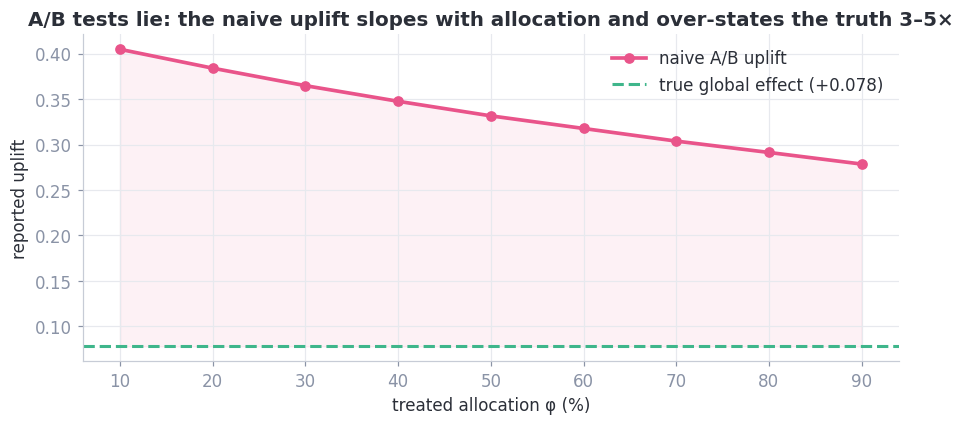

naive uplift: +0.405 at φ=10%  →  +0.279 at φ=90%   (truth +0.078)


In [3]:
def naive_ab(n, phi, seed, **kw):
    rng = np.random.default_rng(seed)
    treat = (rng.random(n) < phi).astype(int)
    p = market_conv(treat, **kw); y = (rng.random(n) < p).astype(int)
    return y[treat == 1].mean() - y[treat == 0].mean()

phis = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
uplift = np.array([np.mean([naive_ab(4000, phi, s) for s in range(80)]) for phi in phis])

fig, ax = plt.subplots(figsize=(8.4, 4))
ax.plot(phis * 100, uplift, "-o", color=PINK, lw=2.4, label="naive A/B uplift")
ax.axhline(TAU, color=GREEN, ls="--", lw=2, label=f"true global effect ({TAU:+.3f})")
ax.fill_between(phis * 100, TAU, uplift, color=PINK, alpha=0.08)
ax.set_xlabel("treated allocation φ (%)"); ax.set_ylabel("reported uplift")
ax.set_title("A/B tests lie: the naive uplift slopes with allocation and over-states the truth 3–5×")
ax.legend(); plt.tight_layout(); plt.show()
print(f"naive uplift: {uplift[0]:+.3f} at φ=10%  →  {uplift[-1]:+.3f} at φ=90%   (truth {TAU:+.3f})")

The naive estimate is **2–5× too big at every allocation** and **decays as $\varphi$ grows** — because at
higher treated share there are fewer control users left to cannibalize, so the apparent "lift" shrinks.
An estimate that depends on the *design knob* is not estimating a causal quantity. This is the
uplift-decay-with-allocation that breaks marketplace experiments.

## 4. The fix — randomize whole markets (cluster randomization)

If we assign **entire markets** to all-treat or all-control, there is **no cross-contamination within a
market**: a treated market is a clean realization of $\mathbf T=\mathbf 1$, a control market of
$\mathbf 0$. The between-market contrast estimates $\tau_{\text{global}}$ directly — and the SE must be
**cluster-robust at the market level** (NB 04), since users within a market are dependent.

cluster-randomized estimate = +0.0787  (bias +0.0006)   cluster-robust coverage of τ_global = 0.96


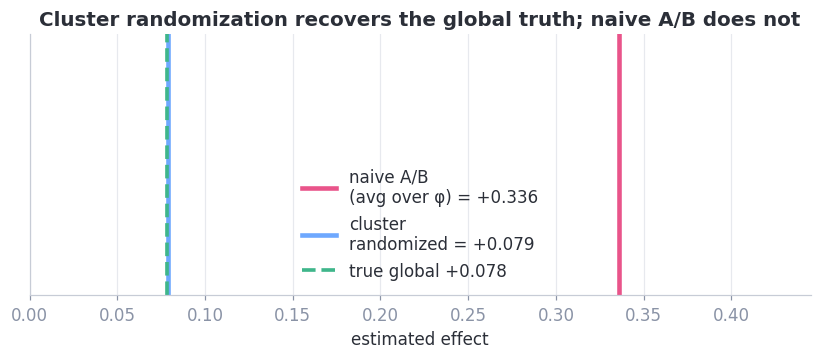

In [4]:
def sim_clustered_market(G, n_g, seed):
    rng = np.random.default_rng(seed)
    tg = np.zeros(G); tg[: G // 2] = 1.0; rng.shuffle(tg)        # half the markets treated
    rows = []
    for g in range(G):
        p = market_conv(np.full(n_g, tg[g])); y = (rng.random(n_g) < p).astype(int)
        rows.append(pd.DataFrame({"g": g, "treat": tg[g].astype(int), "x": tg[g], "y": y}))
    return pd.concat(rows, ignore_index=True)

import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
from lyra.se import se_cv1

est, ses, cov = [], [], 0
for s in range(200):
    df = sim_clustered_market(40, 300, s)
    d = df[df.treat == 1].y.mean() - df[df.treat == 0].y.mean()
    _, se = se_cv1(df); est.append(d); ses.append(se)
    cov += abs(d - TAU) <= 1.96 * se
est = np.array(est)
print(f"cluster-randomized estimate = {est.mean():+.4f}  (bias {est.mean()-TAU:+.4f})   "
      f"cluster-robust coverage of τ_global = {cov/200:.2f}")

fig, ax = plt.subplots(figsize=(7.6, 3.4))
ax.hist(uplift, bins=1, alpha=0)  # spacer
for x, c, lab in [(uplift.mean(), PINK, "naive A/B\n(avg over φ)"), (est.mean(), BLUE, "cluster\nrandomized")]:
    ax.axvline(x, color=c, lw=3, label=f"{lab} = {x:+.3f}")
ax.axvline(TAU, color=GREEN, ls="--", lw=2.4, label=f"true global {TAU:+.3f}")
ax.set_xlim(0, max(uplift) * 1.1); ax.set_yticks([]); ax.set_xlabel("estimated effect")
ax.set_title("Cluster randomization recovers the global truth; naive A/B does not"); ax.legend()
plt.tight_layout(); plt.show()

## 5. The platform verdict — certify the design, not just the number

Because we authored the DGP we can ask the killer question: **does each design's CI actually cover the
truth?** We run the Monte-Carlo harness (the same gate the scorecard uses) on both designs.

NAIVE  user-level A/B : bias +0.254  coverage 0.00  → NOT certified (CI misses the truth)
CLUSTER randomized    : bias -0.001  coverage 0.94  → CERTIFIED


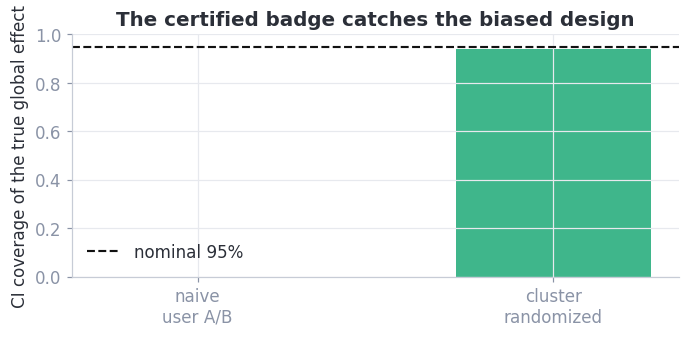

In [5]:
from lyra.dgp import InterferenceDGP            # promoted below — built from this notebook
from lyra.estimators import DiffInMeans
from lyra.se import ClusterOLS
from lyra.harness import harness

naive_rep = harness(DiffInMeans(), InterferenceDGP(design="user"), R=150, n=12000)
clus_rep = harness(ClusterOLS("CV1"), InterferenceDGP(design="cluster"), R=150, n=12000)
print(f"NAIVE  user-level A/B : bias {naive_rep['bias']:+.3f}  coverage {naive_rep['coverage']:.2f}  "
      f"→ {'CERTIFIED' if naive_rep['coverage']>=0.88 else 'NOT certified (CI misses the truth)'}")
print(f"CLUSTER randomized    : bias {clus_rep['bias']:+.3f}  coverage {clus_rep['coverage']:.2f}  "
      f"→ {'CERTIFIED' if clus_rep['coverage']>=0.88 else 'not certified'}")

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.bar(["naive\nuser A/B", "cluster\nrandomized"], [naive_rep["coverage"], clus_rep["coverage"]],
       color=[PINK, GREEN], width=.55)
ax.axhline(0.95, color="#111", ls="--", lw=1.4, label="nominal 95%")
ax.set_ylim(0, 1); ax.set_ylabel("CI coverage of the true global effect")
ax.set_title("The certified badge catches the biased design"); ax.legend(); plt.tight_layout(); plt.show()

**The naive design covers the truth ~0% of the time** — the platform refuses to certify it. The cluster
design covers at ~95% and is certified. *This is the superpower:* the scorecard doesn't just report a
number, it tells you whether the **design** can be trusted.

## 6. Promote → `lyra/dgp` + the platform

`InterferenceDGP` (above, two modes — `user` biased, `cluster` correct; `ground_truth()` = $\tau_{\text{global}}$)
is promoted to `lyra/dgp`; recovery/bias checks in `tests/test_interference.py`. Then we add **two
experiments to the chassis** — a *naive user-level* reward test (which the scorecard marks **uncertified**)
and the *geo-cluster* version (**certified**) — so the dashboard demonstrates the platform catching a
biased analysis. **Next (`ROADMAP.md`): NB 06 — switchback** (temporal interference; recycle `_old/04`).